# BME 2301 2026 Project - Midterm Checkin

# Project Analysis

**Student Name or Names:**  Christopher Liu and Jeffrey Liu
**Project Title:**  How did socioeconomic factors impact covid-19 within Missouri counties?


---

## Part 1 - Project Question

State your current research question clearly:
How do economic factors impact the spread of covid and mortality rates?
> 

---

### In your dataset or sets, what does one row represent?

One row represents a single covid report of a person.

### What does one column represent? (List all appropriate values.)

> County, county code, total covid infections in 2022 in that county, 2022 Population Estimate of the county, 2022 Real GDP of the county, Average Household Income of the county, and COVID-19 infections per capita.
> These represent different metrics that we will use to explore and analyze our research question with.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile


zf = zipfile.ZipFile('COVID-19_Case_Surveillance_Public_Use_Data_with_Geography_20260203.csv.zip')
covid_data = pd.read_csv(zf.open('COVID-19_Case_Surveillance_Public_Use_Data_with_Geography_20260203.csv'), low_memory=False)
covid_data

covid_data.head()
covid_data.info()
covid_data.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1900012 entries, 0 to 1900011
Data columns (total 19 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   case_month                       str    
 1   res_state                        str    
 2   state_fips_code                  int64  
 3   res_county                       str    
 4   county_fips_code                 float64
 5   age_group                        str    
 6   sex                              str    
 7   race                             str    
 8   ethnicity                        str    
 9   case_positive_specimen_interval  float64
 10  case_onset_interval              float64
 11  process                          str    
 12  exposure_yn                      str    
 13  current_status                   str    
 14  symptom_status                   str    
 15  hosp_yn                          str    
 16  icu_yn                           str    
 17  death_yn           

,state_fips_code,county_fips_code,case_positive_specimen_interval,case_onset_interval
count,1900012.0,1.694334e+06,1.892850e+06,424219.000000
mean,29.0,2.913864e+04,3.013995e-01,-0.000846
std,0.0,1.038029e+02,4.866626e+00,0.154015
min,29.0,2.900100e+04,-1.610000e+02,-69.000000
25%,29.0,2.907700e+04,0.000000e+00,0.000000
50%,29.0,2.910100e+04,0.000000e+00,0.000000
75%,29.0,2.918900e+04,0.000000e+00,0.000000
max,29.0,2.951000e+04,1.970000e+02,4.000000


In [5]:
mo_county_population = pd.read_csv("co-est2024-pop-29.csv")
mo_county_population

,table with row headers in column A and column headers in rows 3 through 4 (leading dots indicate sub-parts),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
0,Annual Estimates of the Resident Population fo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Geographic Area,"April 1, 2020 Estimates Base",Population Estimate (as of July 1),NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,2020,2021,2022,2023,2024,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Missouri,"6,154,854","6,154,744","6,171,374","6,179,414","6,208,038","6,245,466",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,".Adair County, Missouri","25,316","25,272","25,188","25,155","25,231","25,660",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,Note: The estimates are developed from a base ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121,Suggested Citation:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
122,Annual Estimates of the Resident Population fo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,"Source: U.S. Census Bureau, Population Division",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Load and show your dataset(s)

## Part 2 — Cleaning Decisions

Identify and justify at least TWO cleaning decisions.

---

### Cleaning Decision 1

What was the issue? 
The Missouri population estimates for each county, and other governmnent csv files, were formatted weirdly and the columns were missing headers when importing the government csv file into python using pandas. This was because they had multiple different labels within the csv file that pandas took as headers or data rows.

What did you do? 
Rows were removed so that the headers were the actual labels for each attribute rather than labels describing the headers. The bottom rows were also removed because they were citing or describing the data rather than it being data points. We also renamed the columns headers because some headers were missing due to the importing process by pandas.

How might this affect results? 
The dataset being formatted more clearly will help us not only be more organized but also just be easier to use later on in the project because we know what each data set represents and does not represent. This will help us in the visualization, exploration, and analysis steps.

---

### Cleaning Decision 2

What was the issue? 
Continous features like population estimate, county gdp, and avg. household income were formatted as strings because they contained symbols such as $ and , in the original csv file. This would result in a type mismatch if we decided to later perform math operations on them such as dividing covid infections by county population to get the per capita value.

What did you do? 
We got rid of any symbols and then converted it to type int.

How might this affect results? 
This will allow us to create new features or perform math operations on it in later steps.

In [8]:
mo_county_population = pd.read_csv("co-est2024-pop-29.csv", header=2, skipfooter = 6, engine='python')

mo_county_population = mo_county_population.rename(columns={
    'Population Estimate (as of July 1)': '2020 Population Estimate',
    'Unnamed: 3': '2021 Population Estimate',
    'Unnamed: 4': '2022 Population Estimate',
    'Unnamed: 5': '2023 Population Estimate',
    'Unnamed: 6': '2024 Population Estimate'
})

mo_county_population = mo_county_population.drop(0)

mo_county_population['Geographic Area'] = mo_county_population['Geographic Area'].str.replace('.', '', regex=False)
mo_county_population['Geographic Area'] = mo_county_population['Geographic Area'].str.replace(', Missouri', '', regex=False)
mo_county_population['Geographic Area'] = mo_county_population['Geographic Area'].str.replace(' County', '', regex=False).str.upper()
mo_county_population = mo_county_population.loc[:, ~mo_county_population.columns.str.contains('^Unnamed')]
mo_county_population = mo_county_population[mo_county_population['Geographic Area'] != 'MISSOURI']

mo_county_population = mo_county_population.reset_index(drop=True)

mo_county_population

,Geographic Area,"April 1, 2020 Estimates Base",2020 Population Estimate,2021 Population Estimate,2022 Population Estimate,2023 Population Estimate,2024 Population Estimate
0,ADAIR,"25,316","25,272","25,188","25,155","25,231","25,660"
1,ANDREW,"18,130","18,102","18,015","18,008","18,109","18,091"
2,ATCHISON,"5,302","5,305","5,210","5,163","5,116","5,139"
3,AUDRAIN,"24,960","24,781","24,858","24,455","24,342","24,304"
4,BARRY,"34,529","34,542","34,762","34,931","35,310","35,618"
...,...,...,...,...,...,...,...
110,WAYNE,"10,973","10,935","10,925","10,807","10,825","10,820"
111,WEBSTER,"39,084","39,008","39,600","40,369","41,481","42,041"
112,WORTH,"1,973","1,968","1,973","1,943","1,903","1,872"
113,WRIGHT,"18,187","18,214","18,625","19,108","19,373","19,505"


In [9]:
mo_county_GDP = pd.read_csv("MO_Counties-GDP_0.csv", header=0, skipfooter = 3, engine='python')

mo_county_GDP_clean = mo_county_GDP.iloc[:, 0:6].copy()
mo_county_GDP_clean = mo_county_GDP_clean.drop([0, 1, 2])

mo_county_GDP_clean.columns = ['County', '2019 Real GDP', '2020 Real GDP', '2021 Real GDP', '2022 Real GDP', '2023 Real GDP']

mo_county_GDP_clean['County'] = mo_county_GDP_clean['County'].str.replace('.', '', regex=False)
mo_county_GDP_clean['County'] = mo_county_GDP_clean['County'].str.replace(', MO', '', regex=False).str.upper()
mo_county_GDP_clean['County'] = mo_county_GDP_clean['County'].str.replace('ST LOUIS (INDEPENDENT CITY)', 'ST LOUIS CITY', regex=False)
mo_county_GDP_clean = mo_county_GDP_clean[mo_county_GDP_clean['County'] != 'MISSOURI']

mo_county_GDP_clean = mo_county_GDP_clean.reset_index(drop=True)

mo_county_GDP_clean

,County,2019 Real GDP,2020 Real GDP,2021 Real GDP,2022 Real GDP,2023 Real GDP
0,ADAIR,"$807,582","$785,869","$798,824","$818,197","$856,741"
1,ANDREW,"$312,660","$318,931","$318,617","$302,785","$308,512"
2,ATCHISON,"$286,286","$316,301","$370,566","$391,949","$389,756"
3,AUDRAIN,"$903,636","$857,671","$884,628","$858,374","$922,972"
4,BARRY,"$1,507,279","$1,452,006","$1,501,693","$1,670,153","$1,588,323"
...,...,...,...,...,...,...
110,WAYNE,"$215,938","$206,803","$214,826","$207,090","$216,356"
111,WEBSTER,"$758,675","$778,276","$867,773","$863,915","$879,885"
112,WORTH,"$57,955","$50,878","$47,247","$43,271","$52,039"
113,WRIGHT,"$326,481","$353,075","$426,532","$435,908","$456,789"


In [10]:
mo_county_avg_household_income = pd.read_csv('HDPulse_data_export.csv', skiprows=3, skipfooter = 8, engine = 'python')

mo_county_avg_household_income = mo_county_avg_household_income.drop([0, 1])
mo_county_avg_household_income = mo_county_avg_household_income.drop(columns=['Rank within US (of 3141 counties)'])

mo_county_avg_household_income = mo_county_avg_household_income.rename(columns={
    'Value (Dollars)': 'Average Household Income'
})
mo_county_avg_household_income['County'] = mo_county_avg_household_income['County'].str.replace(' County', '', regex = False).str.upper()
mo_county_avg_household_income['County'] = mo_county_avg_household_income['County'].str.replace('.', '', regex = False)

mo_county_avg_household_income = mo_county_avg_household_income.reset_index(drop=True)

mo_county_avg_household_income

,County,FIPS,Average Household Income
0,HICKORY,29085,"35,084"
1,PEMISCOT,29155,"40,748"
2,OZARK,29153,"42,329"
3,WAYNE,29223,"43,393"
4,RIPLEY,29181,"43,898"
...,...,...,...
110,LINCOLN,29113,"85,276"
111,CLAY,29047,"86,150"
112,CASS,29037,"87,413"
113,PLATTE,29165,"95,748"


In [27]:
covid_data = covid_data.dropna(subset=['res_county', 'county_fips_code'])
covid_data_2022 = covid_data[covid_data['case_month'].str.startswith('2022')].copy()

covid_infections_by_county_2022 = covid_data_2022.groupby(['res_county', 'county_fips_code']).size().reset_index(name='covid_infections_2022')
covid_infections_by_county_2022['res_county'] = covid_infections_by_county_2022['res_county'].str.replace('.', '', regex=False)
covid_infections_by_county_2022 = covid_infections_by_county_2022.sort_values(by='covid_infections_2022', ascending=False)
covid_infections_by_county_2022 = covid_infections_by_county_2022.reset_index(drop=True)

deaths_2022 = covid_data_2022[covid_data_2022['death_yn'] == 'Yes']
covid_deaths_by_county_2022 = deaths_2022.groupby(['res_county', 'county_fips_code']).size().reset_index(name='covid_deaths_2022')
covid_deaths_by_county_2022['res_county'] = covid_deaths_by_county_2022['res_county'].str.replace('.', '', regex=False)
covid_infections_by_county_2022 = covid_infections_by_county_2022.merge(covid_deaths_by_county_2022, on=['res_county', 'county_fips_code'], how='left')
covid_infections_by_county_2022['covid_deaths_2022'] = covid_infections_by_county_2022['covid_deaths_2022'].fillna(0).astype(int)
covid_infections_by_county_2022

,res_county,county_fips_code,covid_infections_2022,covid_deaths_2022
0,ST LOUIS,29189.0,124171,358
1,JACKSON,29095.0,79621,207
2,ST CHARLES,29183.0,48803,49
3,GREENE,29077.0,33739,75
4,ST LOUIS CITY,29510.0,32679,31
5,CLAY,29047.0,28200,48
6,JEFFERSON,29099.0,26023,62
7,BOONE,29019.0,23705,0
8,JASPER,29097.0,14283,31
9,CASS,29037.0,11391,14


In [29]:
mo_county_population_2022 = mo_county_population[['Geographic Area', '2022 Population Estimate']].copy()
mo_county_GDP_clean_2022 = mo_county_GDP_clean[['County', '2022 Real GDP']].copy()

covid_infections_by_county_2022 = covid_infections_by_county_2022.rename(columns={'res_county': 'County'})
mo_county_population_2022 = mo_county_population_2022.rename(columns={'Geographic Area': 'County'})

merged_data = covid_infections_by_county_2022.merge(mo_county_population_2022, on='County') \
    .merge(mo_county_GDP_clean_2022, on='County') \
    .merge(mo_county_avg_household_income, on='County')

merged_data = merged_data.drop(columns=['FIPS'])

merged_data['2022 Population Estimate'] = merged_data['2022 Population Estimate'].str.replace(',', '').astype(int)
merged_data['Covid Infections Per Capita'] = merged_data['covid_infections_2022']/merged_data['2022 Population Estimate']
merged_data['Covid Deaths Per Capita'] = merged_data['covid_deaths_2022']/merged_data['2022 Population Estimate']

merged_data = merged_data.rename(columns={
    'county_fips_code': 'County FIPS Code',
    'covid_infections_2022': '2022 Covid Infections',
    'covid_deaths_2022': '2022 Covid Deaths'
})

merged_data
merged_data = merged_data.sort_values(by='Covid Infections Per Capita', ascending=False)

merged_data['2022 Real GDP'] = merged_data['2022 Real GDP'].str.replace(r'[\$,]', '', regex = True).astype(int)
merged_data['Average Household Income'] = merged_data['Average Household Income'].str.replace(',', '', regex = True).astype(int)
merged_data

,County,County FIPS Code,2022 Covid Infections,2022 Covid Deaths,2022 Population Estimate,2022 Real GDP,Average Household Income,Covid Infections Per Capita,Covid Deaths Per Capita
22,SCOTT,29201.0,5130,0,37869,1687685,58847,0.135467,0.000000
18,PETTIS,29159.0,5851,0,43381,2217104,60232,0.134875,0.000000
28,DUNKLIN,29069.0,3671,0,27444,755430,47368,0.133763,0.000000
14,ST FRANCOIS,29187.0,8856,0,66938,1736264,54813,0.132302,0.000000
11,BUCHANAN,29021.0,10902,12,82956,4958412,59423,0.131419,0.000145
39,NODAWAY,29147.0,2701,0,20690,746344,55970,0.130546,0.000000
7,BOONE,29019.0,23705,0,187743,9997270,69913,0.126263,0.000000
0,ST LOUIS,29189.0,124171,358,991881,89147507,81340,0.125187,0.000361
37,HENRY,29083.0,2796,0,22404,747657,56621,0.124799,0.000000
43,VERNON,29217.0,2337,0,19608,802593,54519,0.119186,0.000000


## Part 3 - Exploratory Visualization

What variable or other feature are you visualizing?

Why?

The data for covid infections and deaths per county were given as the total. This could muddle our understanding of how covid rates are impacted by socioeconomic factors due to certain counties having a much higher population count than other counties which, by itself, could overshadow the effects of other factors. Therefore, we normalized it by population to better observe how socioeconomic factors in a county may impact covid infections & deaths.

We will create a pair plot of all numerical features to see how different features are correlated with each other to better understand how socioeconomic factors are impacted by each other and how they may impact covid rates.

### Other visualization directly related to your project

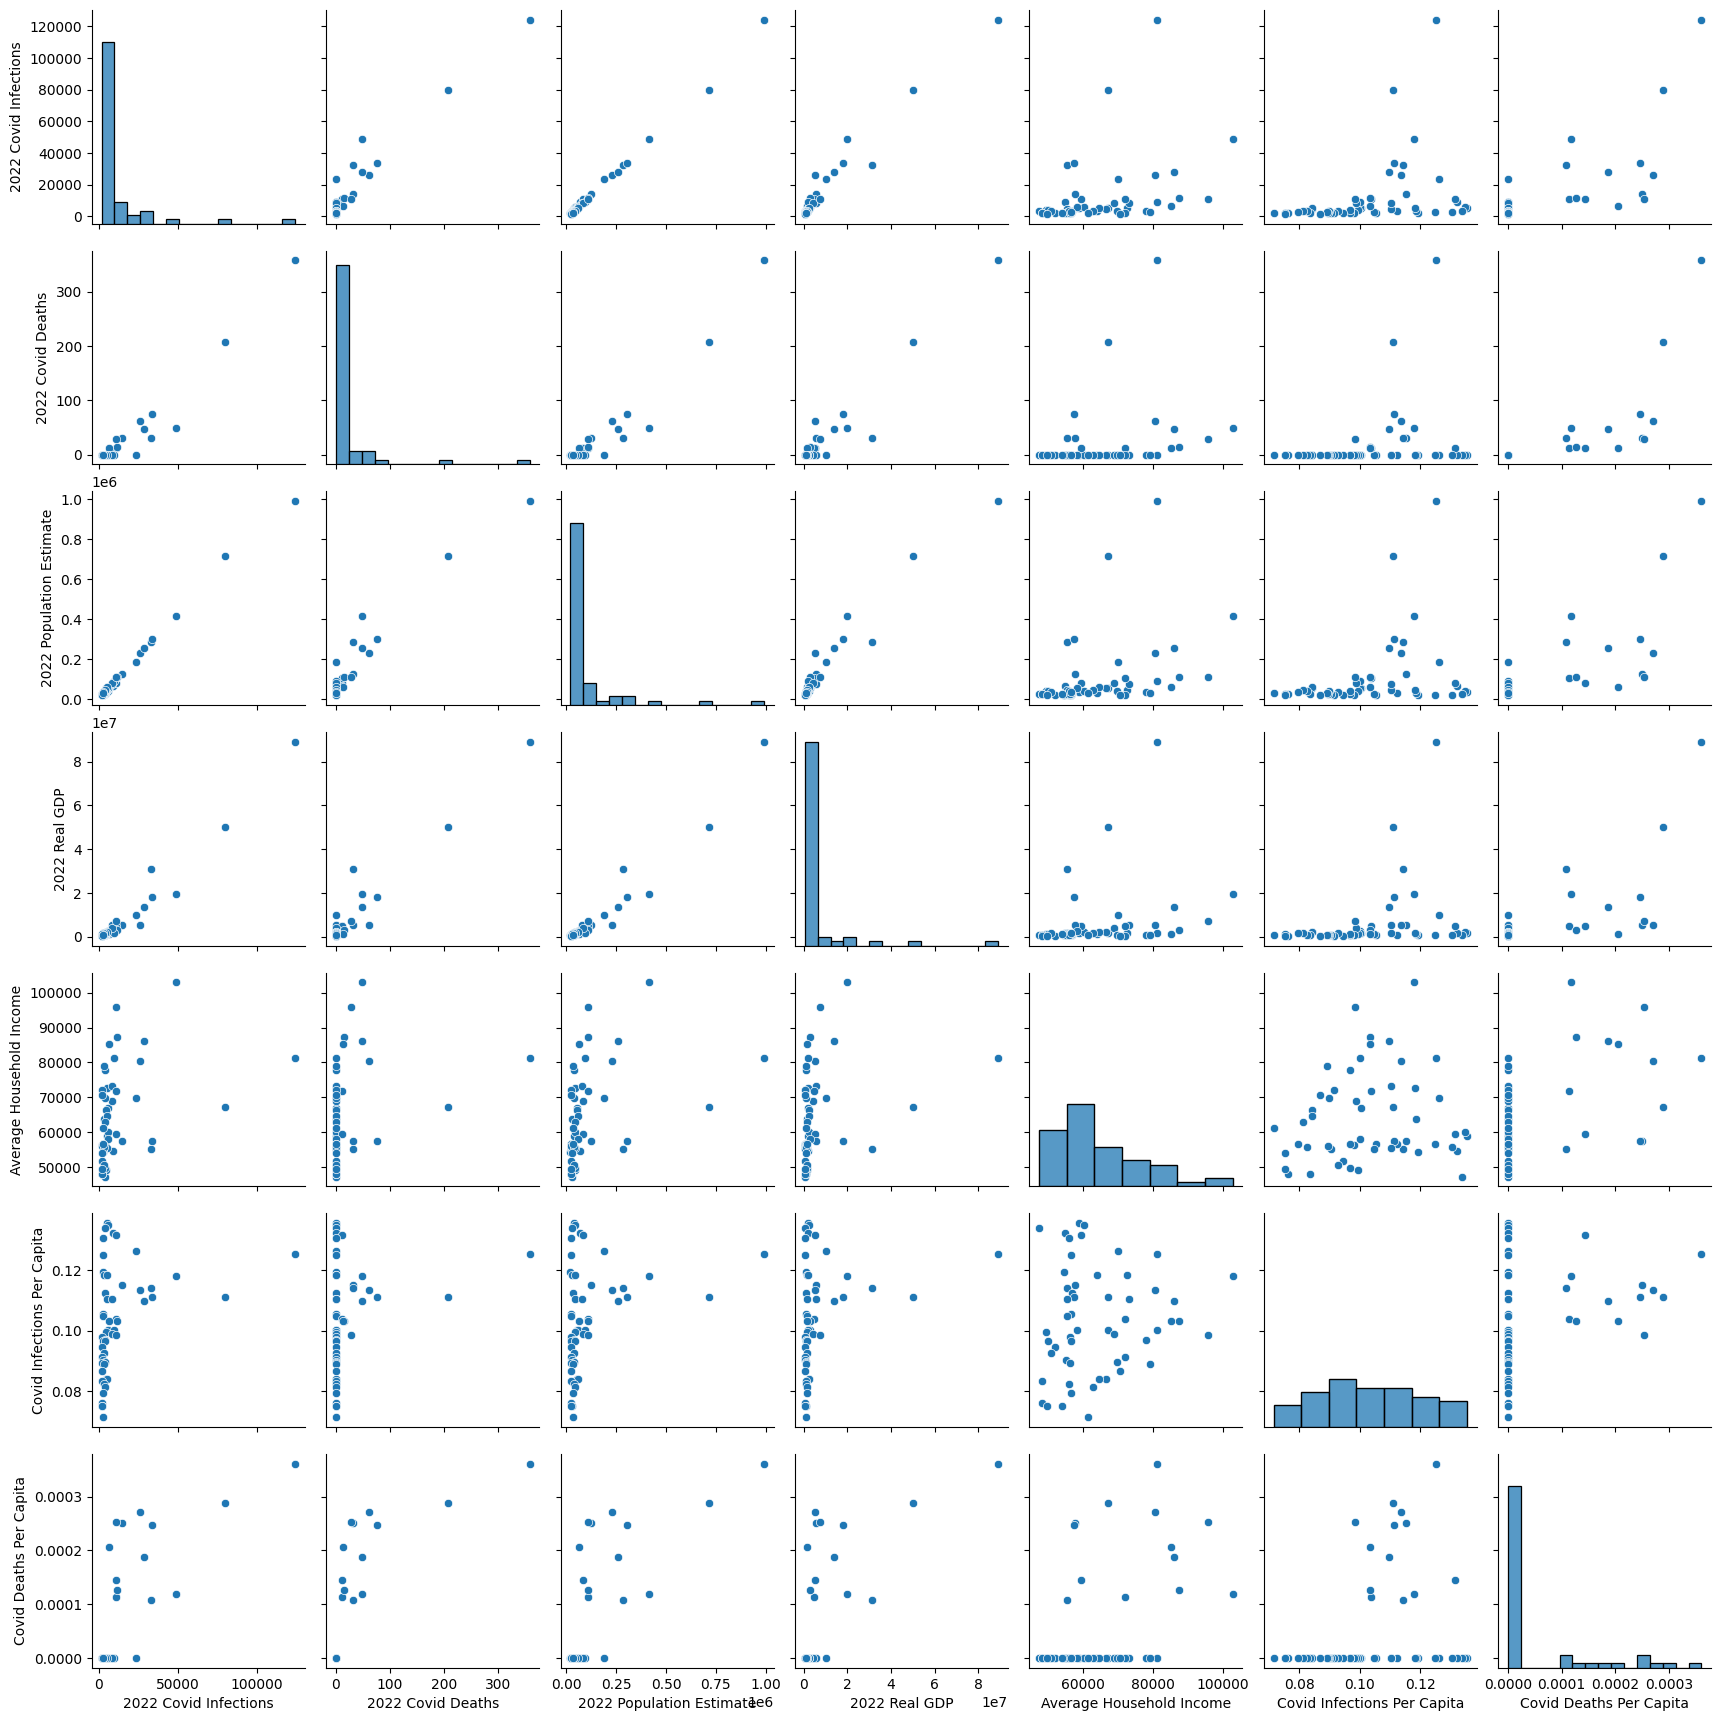

In [31]:
sns.pairplot(merged_data.drop(columns=['County FIPS Code']))

## Part 4 - Statistical and/or Epidemiological Analysis

The plot gives evidence against our hypothesis that a richer county would have lower death rates due to better resources as both county gdp and avg. household income are (somewhat)positively or not correlated with covid infections & deaths per capita. We will do some more exploration to hopefully better understand why. Futhermore, it's concerning that population and gdp are so highly correlated which could pose a problem.

<Axes: >

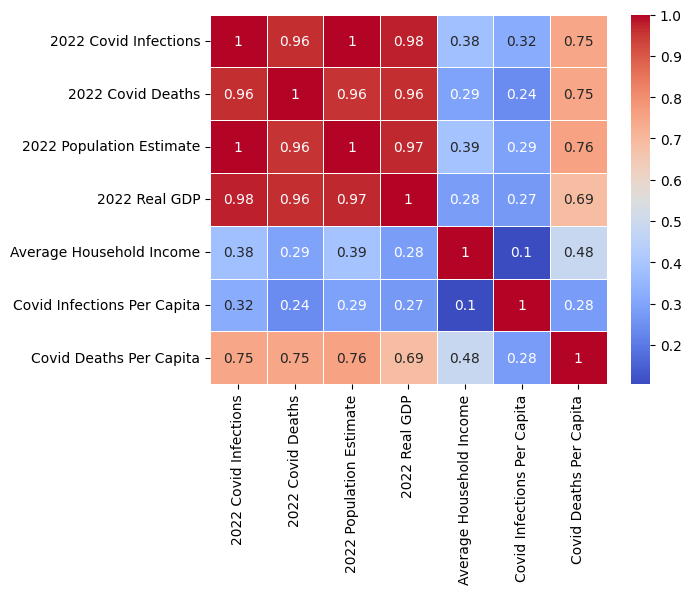

In [34]:
corr_matrix = merged_data.drop(columns=['County FIPS Code']).corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)  

The correlation matrix reveals possible confounding variables between covid infections, covid deaths, population, and gdp. This could pose a problem because it muddles with what we know about each individual feature correlation. For example: is GDP correlated with infections and deaths because it directly increase them? Or is it because gdp increases with population, and its actually population that causes more infections and deaths while gdp just comes along for the ride. And how can this high correlation between population and gdp muddle with our understanding of the data?

In [39]:
threshold = 0.75
print(f"Pairs with correlation > {threshold} or < -{threshold}:\n")

columns = corr_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            print(f"{columns[i]} & {columns[j]}: {corr_value:.2f}")

Pairs with correlation > 0.75 or < -0.75:

2022 Covid Infections & 2022 Covid Deaths: 0.96
2022 Covid Infections & 2022 Population Estimate: 1.00
2022 Covid Infections & 2022 Real GDP: 0.98
2022 Covid Deaths & 2022 Population Estimate: 0.96
2022 Covid Deaths & 2022 Real GDP: 0.96
2022 Population Estimate & 2022 Real GDP: 0.97
2022 Population Estimate & Covid Deaths Per Capita: 0.76


Looking at the feature correlations we see that total covid infections and deaths are highly correlated with gdp as well as population. The problem is that gdp and population are also highly correlated so the relationship between these variables are tangled.

We do not see covid infections per capita in any relationship within this high correlation list.

We also observe that only population has a correlation with covid deaths per capita above the threshold, with gdp being absent. Firstly, this suggests that population is not only correlated with covid deaths purely because "more poeple so more deaths" as it is also highly correlated with covid deaths per capita. This suggests that covid deaths is disproportionately higher when population increases. The absence of gdp in this high correlation list with covid deaths per capita suggests that population is a stronger driver for deaths. Although, gdp is not much lower with a correlation of 0.69, the correlation difference between the two being 0.76 - 0.69 = 0.07 is still larger than their original correlation difference with total coivd deaths(0.96 - 0.96 = 0). This difference may be because a county's population has a large impact on its gdp. And so, when population was normalized it dropped off slightly.

A correlation of 0.69 between a county's gdp and its covid death rate is still pretty high. However, we can't say for certain that the correlation is caused purely by gdp or it still being dragged by population.

On the surface, these insights don't give us any new information that we did not know. It is common sense that as population increases within a county, there are more chances of getting infected. However, we now have more leads to look into such as: Why is death rate postively correlated with gdp when one would think more resources could help prevent deaths? Would this be because people would just drive to counties that have more resources and have better hospitals? Would these deaths count as deaths in their home county or the county the hospital is located in? Was our medical system just not able to deal with covid during 2022? Is the relationship between population and gdp just too intertwined?

We also just looked at population and did not account for population density which may be an even stronger contributing factor to covid rates. By adding population density in our correlation and pair plot we could also observe how population density affects gdp and household income to see if pure population count or population density is a stronger determining factor or county weatlh.

Even though we have some leads, it isn't clear what direction we can head in which may mean we have to change our project to another direction.

## Part 5 - Assumptions and Limitations
Identify at least three assumptions underlying your analysis.

1. Our first assumption is that covid data were reported with equal accuracy and coverage across all counties. This matters because to be able to compare the data across all counties we need to assume they are all collected in the same consistent matter. In reality, this may not be the case as poorer, rural counties may have less consistent reports. If this is the case, then we can't accurately compare the metrics across counties. Richer counties may just have more resources to test patients which makes it look like richer counties have higher covid infection and death rates, thereby suggesting gdp and household income causes higher spread/deaths, when in actuality they just have more testing/reporting resources.

2. Another assumption in the data is that the covid report of a person is directly tied to their home county. This matters because we need to assume that the person was infected in their county and then they were tested in their county and then counted towards their county covid rates. Otherwise, we can't be certain how socioeconomic factors like a county's wealth, which could give us clues about a county's job opportunities, type of job (which may affect social distancing, the need to work in person), or how active people are in their local economy such as going shopping could affect covid infection rates. If this was violated such as if people were tested in another county and then it counted towards the test county's covid report, then the data gets jumbled.

3. Another assumption is that people relied strictly on their own county's resources, especially if death was an outcome. This is important because we want to measure our a county's wealth impacts the resources and their ability to treat covid. If people drove to richer counties with better hospitals then it skews the data because then it would look like richer counties had more deaths when in actuallity it was because critically ill people from other counties were going to the better hospitals located in richer counties and then dying there. 

For each:
- Why does it matter?
- What happens if it is violated?

2.6 Part 6 - Reflection and Next Steps

Discuss what you've learned so far and what you plan to do next.

So far, the data suggests that population is the strongest factor for covid death rates. The data does not support our original hypothesis that a wealthier county would have less deaths due to a county having more resources. Furthermore, the data is harder to analyze than we originally thought due to high correlation between features. 

Covid infections per capita has very low correlation with gdp or household income. Covid deaths per capita has moderately high correlation with gdp and population.

We can't say for certain if population and gdp are directly correlated with covid deaths or if there are some indirect links between the two due to their extremely high correlation with each other.  

For our next steps, we will add in age and vaccination rates to our data set as age heavily impacts covid deaths as well as vaccinations. We could explore if wealthier counties have older citizens by downloading age demographic data of missouri counties. We could also explore how covid vaccinations rates are in each county and if county wealth impacts vaccination rates or not. These factors may be a stronger factor of covid infections & deaths than more general metrics likes population size and gdp. If these features are promising, a further goal will be modeling our dataset using xgboost or rule based regression models( cubist or rulefit) to deal with the highly correlated features which will help us see just how heavily each feature contributes to covid infections and deaths using their feature importance charts.